# 📓 Accessing data from DHS API for National Trends
**Indicator:** Stunting (CN_NUTR_C_HA2)

In [12]:
import requests
import pandas as pd

# This endpoint lists all indicators AVAILABLE for Ethiopia specifically
url = "http://api.dhsprogram.com/rest/dhs/indicators"
params = {"countryIds": "ET", "f": "json"}

resp = requests.get(url, params=params).json()
indicators_df = pd.DataFrame(resp['Data'])
indicators_df.head()

,Definition,NumberScale,IndicatorType,MeasurementType,IsQuickStat,ShortName,IndicatorId,Level1,IndicatorTotalId,Level2,...,IndicatorOldId,TagIds,DenominatorWeightedId,Label,IndicatorOrder,Denominator,QuickStatOrder,IndicatorSpecial1Id,DenominatorUnweightedId,IndicatorSpecial2Id
0,Age-specific fertility rate for the three year...,0,I,Rate,0,ASFR 10-14,FE_FRTR_W_A10,Fertility,,Fertility rates,...,,80,,Age specific fertility rate: 10-14,11763005,Per thousand women years exposed in the period...,,,,
1,Age-specific fertility rate for the three year...,0,I,Rate,0,ASFR 15-19,FE_FRTR_W_A15,Fertility,,Fertility rates,...,19165001,"74, 1, 7, 81, 80",,Age specific fertility rate: 15-19,11763010,Per thousand women years exposed in the period...,,,,
2,Age-specific fertility rate for the three year...,0,I,Rate,0,ASFR 20-24,FE_FRTR_W_A20,Fertility,,Fertility rates,...,19165002,74,,Age specific fertility rate: 20-24,11763020,Per thousand women years exposed in the period...,,,,
3,Age-specific fertility rate for the three year...,0,I,Rate,0,ASFR 25-29,FE_FRTR_W_A25,Fertility,,Fertility rates,...,19165003,74,,Age specific fertility rate: 25-29,11763030,Per thousand women years exposed in the period...,,,,
4,Age-specific fertility rate for the three year...,0,I,Rate,0,ASFR 30-34,FE_FRTR_W_A30,Fertility,,Fertility rates,...,19165004,74,,Age specific fertility rate: 30-34,11763040,Per thousand women years exposed in the period...,,,,


In [4]:
indicators_df.columns

Index(['Definition', 'NumberScale', 'IndicatorType', 'MeasurementType',
       'IsQuickStat', 'ShortName', 'IndicatorId', 'Level1', 'IndicatorTotalId',
       'Level2', 'Level3', 'SDRID', 'IndicatorOldId', 'TagIds',
       'DenominatorWeightedId', 'Label', 'IndicatorOrder', 'Denominator',
       'QuickStatOrder', 'IndicatorSpecial1Id', 'DenominatorUnweightedId',
       'IndicatorSpecial2Id'],
      dtype='object')

In [13]:
# Search for "stunting" in the labels to find the active ID
stunting_search = indicators_df[indicators_df['Label'].str.contains("death", case=False)]
print(stunting_search[['IndicatorId', 'Label']])

        IndicatorId                                          Label
1077  CM_PNMR_C_NEN                          Early neonatal deaths
1083  CM_PNMR_C_RSE  Ratio of stillbirths to early neonatal deaths
1162  MM_AMRT_W_DTH                          Deaths of adult women
1166  MM_AMRT_M_DTH                            Deaths of adult men
1172  MM_MMRT_W_FDP       Female deaths that are pregnancy-related
1173  MM_MMRT_W_FDM                Female deaths that are maternal
1174  MM_MMRT_W_PDT             Number of pregnancy-related deaths
1175  MM_MMRT_W_MDT                      Number of maternal deaths
1183  MM_MMRO_W_LTP       Lifetime risk of pregnancy-related death
1187  MM_MMRO_W_LTR                Lifetime risk of maternal death


In [32]:
import requests
import pandas as pd
import plotly.express as px

# Corrected API endpoint for data
url = "http://api.dhsprogram.com/rest/dhs/data"
params = {
    "countryIds": "ET",
    "indicatorIds": "MM_AMRT_M_DTH",  # Corrected from NUTR to NUTS
    "f": "json"
}

# 2. Fetch the data
response = requests.get(url, params=params)
res_json = response.json()

# 3. Process and Plot
if "Data" in res_json and len(res_json["Data"]) > 0:
    df = pd.DataFrame(res_json["Data"])
    
    # Cleaning data types
    df["Value"] = pd.to_numeric(df["Value"], errors='coerce')
    df["SurveyYear"] = pd.to_numeric(df["SurveyYear"])
    
    # Sorting by year ensures the trend line flows correctly
    df = df.sort_values("SurveyYear")
    
    # Generate the chart
    fig = px.line(df, x="SurveyYear", y="Value", markers=True, 
                 title="Ethiopia National Underweight Trend (Children severely underweight)")
    fig.show()
else:
    print("⚠️ Data still empty. Check your connection to api.dhsprogram.com.")

### To save in csv

In [ ]:
import requests
import pandas as pd
import plotly.express as px

# Corrected API endpoint for data
url = "http://api.dhsprogram.com/rest/dhs/data"
params = {
    "countryIds": "ET",
    "indicatorIds": "MM_MMRT_W_FDP",  # Corrected from NUTR to NUTS
    "f": "json"
}

# 2. Fetch the data
response = requests.get(url, params=params)
res_json = response.json()

# 3. Process and Plot
if "Data" in res_json and len(res_json["Data"]) > 0:
    df = pd.DataFrame(res_json["Data"])
    
    # Cleaning data types
    df["Value"] = pd.to_numeric(df["Value"], errors='coerce')
    df["SurveyYear"] = pd.to_numeric(df["SurveyYear"])
    
    # Sorting by year ensures the trend line flows correctly
    df = df.sort_values("SurveyYear")
    #Save to specific folder
    output_path = r"C:/Users/user/Desktop/collection/ethiopia_underweight_trend.csv"
    df.to_csv(output_path, index=False)

print(f"Data saved to {output_path}")
    # Generate the chart
fig = px.line(df, x="SurveyYear", y="Value", markers=True, title="Ethiopia National Underweight Trend (Children severely underweight)")
fig.show()


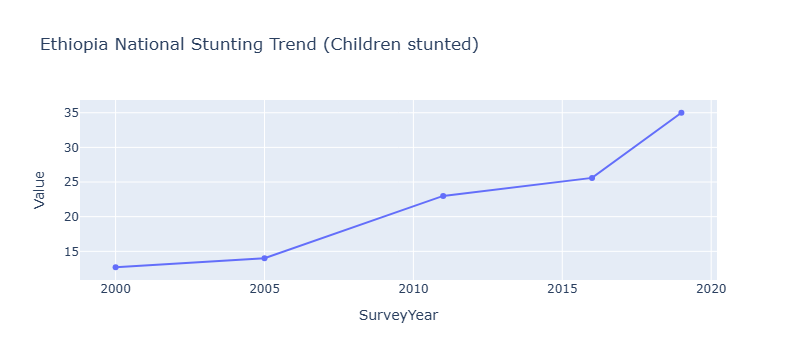

In [16]:
import requests
import pandas as pd
import plotly.express as px
import altair as alt

# Corrected API endpoint for data
url = "http://api.dhsprogram.com/rest/dhs/data"
params = {
    "countryIds": "ET",
    "indicatorIds": "HC_ELEC_H_ELC",  # Corrected from NUTR to NUTS
    "f": "json"
}

# 2. Fetch the data
response = requests.get(url, params=params)
res_json = response.json()

# 3. Process and Plot
if "Data" in res_json and len(res_json["Data"]) > 0:
    df = pd.DataFrame(res_json["Data"])
    
    # Cleaning data types
    df["Value"] = pd.to_numeric(df["Value"], errors='coerce')
    df["SurveyYear"] = pd.to_numeric(df["SurveyYear"])
    
    # Sorting by year ensures the trend line flows correctly
    df = df.sort_values("SurveyYear")
    
    # Generate the chart
    fig = px.line(df, x="SurveyYear", y="Value", markers=True, 
                 title="Ethiopia National Stunting Trend (Children stunted)")
    fig.show()
else:
    print("⚠️ Data still empty. Check your connection to api.dhsprogram.com.")

In [20]:
import requests
import pandas as pd
import plotly.express as px
import altair as alt

# Corrected API endpoint for data
url = "http://api.dhsprogram.com/rest/dhs/data"
params = {
    "countryIds": "ET",
    "indicatorIds": "HC_ELEC_H_ELC",  # Corrected from NUTR to NUTS
    "f": "json"
}

# 2. Fetch the data
response = requests.get(url, params=params)
res_json = response.json()

# 3. Process and Plot
if "Data" in res_json and len(res_json["Data"]) > 0:
    df = pd.DataFrame(res_json["Data"])
    
    # Cleaning data types
    df["Value"] = pd.to_numeric(df["Value"], errors='coerce')
    df["SurveyYear"] = pd.to_numeric(df["SurveyYear"])
    
    # Sorting by year ensures the trend line flows correctly
    df = df.sort_values("SurveyYear")
    
    # Generate the chart
    alt_chart = alt.Chart(df).mark_line(point=True).encode(
        x = alt.X("SurveyYear:T"),
        y = alt.Y("Value:Q"),
        color = alt.Color("RegionId")
    )
else:
    print("⚠️ Data still empty. Check your connection to api.dhsprogram.com.")

alt_chart

alt.Chart(...)

In [19]:
df.shape

(5, 28)

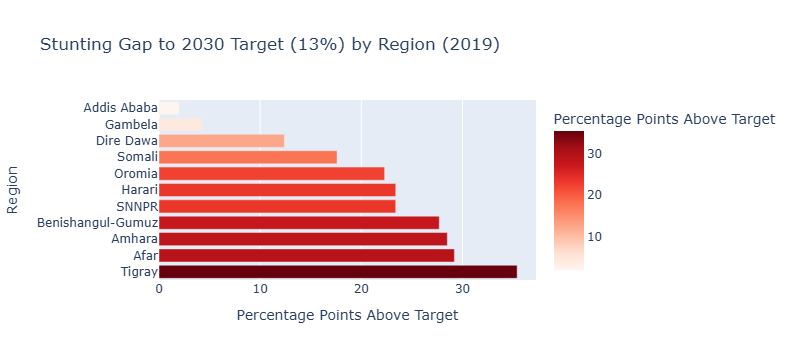

In [13]:
import requests
import pandas as pd
import plotly.express as px

# 1. Fetch Subnational (Regional) data for Ethiopia
# Corrected API endpoint for data
url = "http://api.dhsprogram.com/rest/dhs/data"
params = {
    "countryIds": "ET",
    "indicatorIds": "CN_NUTS_C_HA2",
    "breakdown": "subnational", # Crucial for regional data
    "f": "json"
}

response = requests.get(url, params=params)
data = response.json()["Data"]

# 2. Process data
df_reg = pd.DataFrame(data)
df_reg["Value"] = pd.to_numeric(df_reg["Value"], errors='coerce')
df_reg["SurveyYear"] = pd.to_numeric(df_reg["SurveyYear"])

# 3. Filter for the latest survey (2016 or 2019)
latest_year = df_reg["SurveyYear"].max()
df_latest = df_reg[df_reg["SurveyYear"] == latest_year].copy()

# 4. Calculate the "Gap to 2030 Target" (13.0%)
target_2030 = 13.0
df_latest["Gap_to_Target"] = df_latest["Value"] - target_2030

# 5. Visualize the regional disparities
fig = px.bar(df_latest.sort_values("Gap_to_Target", ascending=False), 
             x="Gap_to_Target", y="CharacteristicLabel", orientation='h',
             title=f"Stunting Gap to 2030 Target (13%) by Region ({latest_year})",
             labels={"Gap_to_Target": "Percentage Points Above Target", 
                     "CharacteristicLabel": "Region"},
             color="Gap_to_Target", color_continuous_scale="Reds")
fig.show()

In [15]:
pd.concat([df_reg, df_reg, df_reg])

,DataId,SurveyId,Indicator,IsPreferred,Value,SDRID,Precision,RegionId,SurveyYearLabel,SurveyType,...,IndicatorId,CharacteristicOrder,CharacteristicLabel,ByVariableLabel,DenominatorUnweighted,DenominatorWeighted,CIHigh,IsTotal,ByVariableId,LevelRank
0,3657529,ET2000DHS,Children stunted,1,61.2,CNNUTSCHA2,1,ETDHS2000406001,2000,DHS,...,CN_NUTS_C_HA2,1406001,Tigray,,1000.0,697.0,,0,0,1
1,2654085,ET2000DHS,Children stunted,1,53.1,CNNUTSCHA2,1,ETDHS2000406002,2000,DHS,...,CN_NUTS_C_HA2,1406002,Afar,,503.0,95.0,,0,0,1
2,5200750,ET2000DHS,Children stunted,1,63.0,CNNUTSCHA2,1,ETDHS2000406003,2000,DHS,...,CN_NUTS_C_HA2,1406003,Amhara,,1388.0,2723.0,,0,0,1
3,4775194,ET2000DHS,Children stunted,1,53.9,CNNUTSCHA2,1,ETDHS2000406004,2000,DHS,...,CN_NUTS_C_HA2,1406004,Oromia,,1883.0,4307.0,,0,0,1
4,3938117,ET2000DHS,Children stunted,1,51.8,CNNUTSCHA2,1,ETDHS2000406005,2000,DHS,...,CN_NUTS_C_HA2,1406005,Somali,,427.0,83.0,,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,4224019,ET2019DHS,Children stunted,1,36.4,CNNUTSCHA2,1,ETDHS2019406007,2019,DHS,...,CN_NUTS_C_HA2,1406007,SNNPR,,645.0,1078.0,,0,0,1
51,7043379,ET2019DHS,Children stunted,1,17.3,CNNUTSCHA2,1,ETDHS2019406012,2019,DHS,...,CN_NUTS_C_HA2,1406022,Gambela,,412.0,21.0,,0,0,1
52,3623487,ET2019DHS,Children stunted,1,36.4,CNNUTSCHA2,1,ETDHS2019406013,2019,DHS,...,CN_NUTS_C_HA2,1406023,Harari,,416.0,15.0,,0,0,1
53,7809806,ET2019DHS,Children stunted,1,15.0,CNNUTSCHA2,1,ETDHS2019406014,2019,DHS,...,CN_NUTS_C_HA2,1406024,Addis Ababa,,271.0,144.0,,0,0,1


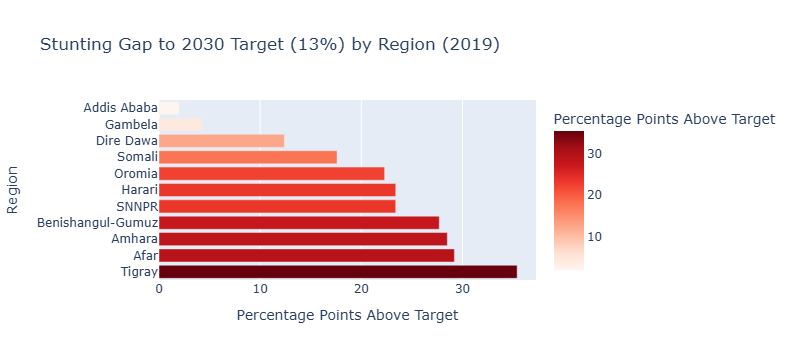

In [21]:
import requests
import pandas as pd
import plotly.express as px

# 1. Fetch Subnational (Regional) data for Ethiopia
# Corrected API endpoint for data
url = "http://api.dhsprogram.com/rest/dhs/data"
params = {
    "countryIds": "ET",
    "indicatorIds": "CN_NUTS_C_HA2",
    "breakdown": "subnational", # Crucial for regional data
    "f": "json"
}

response = requests.get(url, params=params)
data = response.json()["Data"]

# 2. Process data
df_reg = pd.DataFrame(data)
df_reg["Value"] = pd.to_numeric(df_reg["Value"], errors='coerce')
df_reg["SurveyYear"] = pd.to_numeric(df_reg["SurveyYear"])

# 3. Filter for the latest survey (2016 or 2019)
latest_year = df_reg["SurveyYear"].max()
df_latest = df_reg[df_reg["SurveyYear"] == latest_year].copy()

# 4. Calculate the "Gap to 2030 Target" (13.0%)
target_2030 = 13.0
df_latest["Gap_to_Target"] = df_latest["Value"] - target_2030

# 5. Visualize the regional disparities
fig = px.bar(df_latest.sort_values("Gap_to_Target", ascending=False), 
             x="Gap_to_Target", y="CharacteristicLabel", orientation='h',
             title=f"Stunting Gap to 2030 Target (13%) by Region ({latest_year})",
             labels={"Gap_to_Target": "Percentage Points Above Target", 
                     "CharacteristicLabel": "Region"},
             color="Gap_to_Target", color_continuous_scale="Reds")
fig.show()

In [22]:
df_reg

,DataId,SurveyId,Indicator,IsPreferred,Value,SDRID,Precision,RegionId,SurveyYearLabel,SurveyType,...,IndicatorId,CharacteristicOrder,CharacteristicLabel,ByVariableLabel,DenominatorUnweighted,DenominatorWeighted,CIHigh,IsTotal,ByVariableId,LevelRank
0,3657529,ET2000DHS,Children stunted,1,61.2,CNNUTSCHA2,1,ETDHS2000406001,2000,DHS,...,CN_NUTS_C_HA2,1406001,Tigray,,1000.0,697.0,,0,0,1
1,2654085,ET2000DHS,Children stunted,1,53.1,CNNUTSCHA2,1,ETDHS2000406002,2000,DHS,...,CN_NUTS_C_HA2,1406002,Afar,,503.0,95.0,,0,0,1
2,5200750,ET2000DHS,Children stunted,1,63.0,CNNUTSCHA2,1,ETDHS2000406003,2000,DHS,...,CN_NUTS_C_HA2,1406003,Amhara,,1388.0,2723.0,,0,0,1
3,4775194,ET2000DHS,Children stunted,1,53.9,CNNUTSCHA2,1,ETDHS2000406004,2000,DHS,...,CN_NUTS_C_HA2,1406004,Oromia,,1883.0,4307.0,,0,0,1
4,3938117,ET2000DHS,Children stunted,1,51.8,CNNUTSCHA2,1,ETDHS2000406005,2000,DHS,...,CN_NUTS_C_HA2,1406005,Somali,,427.0,83.0,,0,0,1
5,6182362,ET2000DHS,Children stunted,1,49.7,CNNUTSCHA2,1,ETDHS2000406006,2000,DHS,...,CN_NUTS_C_HA2,1406006,Benishangul-Gumuz,,671.0,102.0,,0,0,1
6,180981,ET2000DHS,Children stunted,1,60.8,CNNUTSCHA2,1,ETDHS2000406007,2000,DHS,...,CN_NUTS_C_HA2,1406007,SNNPR,,1389.0,2251.0,,0,0,1
7,4180675,ET2000DHS,Children stunted,1,41.7,CNNUTSCHA2,1,ETDHS2000406012,2000,DHS,...,CN_NUTS_C_HA2,1406022,Gambela,,497.0,23.0,,0,0,1
8,6476463,ET2000DHS,Children stunted,1,42.1,CNNUTSCHA2,1,ETDHS2000406013,2000,DHS,...,CN_NUTS_C_HA2,1406023,Harari,,491.0,21.0,,0,0,1
9,7969340,ET2000DHS,Children stunted,1,32.9,CNNUTSCHA2,1,ETDHS2000406014,2000,DHS,...,CN_NUTS_C_HA2,1406024,Addis Ababa,,466.0,166.0,,0,0,1


In [23]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Example: Forecast for a High-Burden Region (e.g., Amhara)
# X = Historical DHS Years, y = Stunting Values (%)
years = np.array([2000, 2005, 2011, 2016, 2019]).reshape(-1, 1)
values = np.array([58.0, 51.5, 44.4, 46.3, 41.0]) # Illustrative values

# Train the model
model = LinearRegression()
model.fit(years, values)

# Predict for 2030
year_2030 = np.array([[2030]])
forecast_2030 = model.predict(year_2030)

print(f"Projected Stunting in 2030: {forecast_2030[0]:.2f}%")
print(f"Required Annual Reduction to hit 13%: {(values[-1] - 13.0) / (2030 - 2019):.2f}% per year")

Projected Stunting in 2030: 32.38%
Required Annual Reduction to hit 13%: 2.55% per year


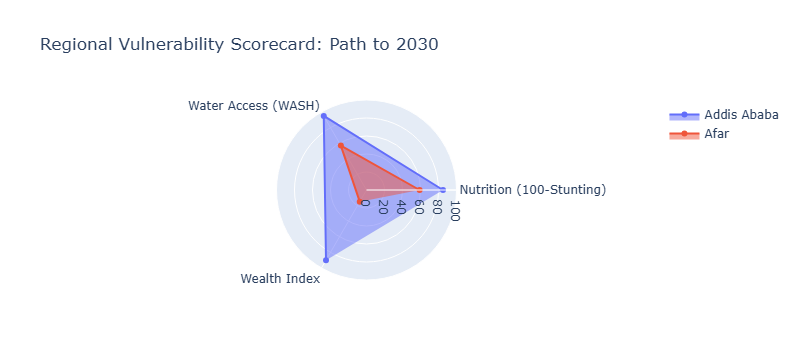

In [24]:
import plotly.graph_objects as go

# Metrics for two sample regions (e.g., Addis Ababa and Afar)
# Scores are normalized to a 0-100 scale for comparison
categories = ['Nutrition (100-Stunting)', 'Water Access (WASH)', 'Wealth Index']

fig = go.Figure()

# Trace for Addis Ababa (Typically high performing)
fig.add_trace(go.Scatterpolar(
      r=[85, 95, 90], # Sample normalized scores
      theta=categories,
      fill='toself',
      name='Addis Ababa'
))

# Trace for Afar (High-priority region for 2030)
fig.add_trace(go.Scatterpolar(
      r=[59, 57, 15], # Sample normalized scores
      theta=categories,
      fill='toself',
      name='Afar'
))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 100]
    )),
  showlegend=True,
  title="Regional Vulnerability Scorecard: Path to 2030"
)

fig.show()

In [25]:
import pandas as pd

# Define the Priority Matrix based on the 2030 Roadmap
def get_action_plan(row):
    if row['Stunting'] > 40:
        return "CRITICAL: Scale-up Multisectoral Seqota Expansion (WASH + Nutrition)"
    elif row['Water_Access'] < 30:
        return "HIGH: Prioritize 'One WASH' Infrastructure & Handwashing"
    elif row['Stunting'] > 25:
        return "MODERATE: Focused Micronutrient (Vitamin A & Zinc) Supplementation"
    else:
        return "MAINTAIN: Community-based Health Extension Support"

# Example Data for 2026 Policy Review
data = {
    'Region': ['Amhara', 'Afar', 'Addis Ababa', 'Oromia', 'Somali'],
    'Stunting': [41.0, 48.0, 14.0, 36.5, 29.0],
    'Water_Access': [45.0, 25.0, 92.0, 38.0, 22.0]
}

df_action = pd.DataFrame(data)
df_action['Recommended_Action'] = df_action.apply(get_action_plan, axis=1)

# Display the Action Plan
print("🇪🇹 2030 National Nutrition Program: Regional Action Plan")
print(df_action[['Region', 'Stunting', 'Recommended_Action']].sort_values('Stunting', ascending=False))

🇪🇹 2030 National Nutrition Program: Regional Action Plan
        Region  Stunting                                 Recommended_Action
1         Afar      48.0  CRITICAL: Scale-up Multisectoral Seqota Expans...
0       Amhara      41.0  CRITICAL: Scale-up Multisectoral Seqota Expans...
3       Oromia      36.5  MODERATE: Focused Micronutrient (Vitamin A & Z...
4       Somali      29.0  HIGH: Prioritize 'One WASH' Infrastructure & H...
2  Addis Ababa      14.0  MAINTAIN: Community-based Health Extension Sup...


In [26]:
df

,DataId,SurveyId,Indicator,IsPreferred,Value,SDRID,Precision,RegionId,SurveyYearLabel,SurveyType,...,IndicatorId,CharacteristicOrder,CharacteristicLabel,ByVariableLabel,DenominatorUnweighted,DenominatorWeighted,CIHigh,IsTotal,ByVariableId,LevelRank
0,204661,ET2000DHS,Children stunted,1,57.7,CNNUTSCHA2,1,,2000,DHS,...,CN_NUTS_C_HA2,0,Total,,9214.0,10503.0,,1,0,
1,238383,ET2005DHS,Children stunted,1,50.8,CNNUTSCHA2,1,,2005,DHS,...,CN_NUTS_C_HA2,0,Total,,4105.0,4567.0,,1,0,
2,420487,ET2011DHS,Children stunted,1,44.4,CNNUTSCHA2,1,,2011,DHS,...,CN_NUTS_C_HA2,0,Total,,10282.0,10883.0,,1,0,
3,377971,ET2016DHS,Children stunted,1,38.4,CNNUTSCHA2,1,,2016,DHS,...,CN_NUTS_C_HA2,0,Total,,9471.0,10376.0,,1,0,
4,731645,ET2019DHS,Children stunted,1,36.8,CNNUTSCHA2,1,,2019,DHS,...,CN_NUTS_C_HA2,0,Total,,5380.0,5279.0,,1,0,
